# **Текстовый поиск**

Текстовый поиск - это процесс нахождения в большом множестве текстовых
документов тех, которые наиболее соответствуют заданному пользователем
запросу по содержанию или смыслу.

Он включает:

• анализ запроса и текста документов

• сопоставление терминов и выражений

• оценку релевантности

• ранжирование найденных результатов



In [ ]:
!pip install rank_bm25

In [ ]:
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np

from rank_bm25 import BM25Okapi

### Предобработка текста

Цель: очистить и нормализовать текстовую коллекцию

In [ ]:
new_texts = [
    "Искусственный интеллект 21 века быстро обрабатывает большие объемы данных!",
    "Новые технологии машинного обучения используются в современной медицине 4.0.",
    "Роботы, автоматизация и другие инновации меняют нашу промышленность на 100%."
]

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text)
    words = text.split()
    return [w for w in words]

clean_new_texts = [preprocess(t) for t in new_texts]
print("После препроцессинга:")
for i, text in enumerate(clean_new_texts):
    print(f"Text {i+1}: {text}")

## Задание 1: Улучшение препроцессинга текста

1.  **Улучшение функции препроцессинга текста**: Преобразуйте приведённую выше функцию `preprocess` для более эффективной очистки и нормализации текста с учётом специфики задачи текстового поиска. Для этого уберите стоп-слова, воспользовавшись списком стоп-слов библиотеки `nltk`, и примените стемминг (Используйте `SnowballStemmer`).





### Реализация поиска по TF-IDF

Цель: реализовать базовую модель поиска и ранжирования документов.

Для TF-IDF предварительно обработанные токены будут объединены в строки.

In [ ]:
# Создание корпуса документов и запросов
docs = [
    "Искусственный интеллект трансформирует многие отрасли, включая медицину и финансы. Нейронные сети и глубокое обучение используются для анализа больших данных.",
    "Машинное обучение играет ключевую роль в современных технологиях, от рекомендательных систем до беспилотных автомобилей. Модели постоянно улучшаются.",
    "Робототехника и автоматизация меняют производственные процессы, повышая эффективность и снижая затраты. Промышленные роботы становятся всё более адаптивными.",
    "Анализ данных с использованием статистики и алгоритмов помогает принимать обоснованные бизнес-решения. Визуализация данных упрощает понимание сложных отчётов.",
    "Компьютерное зрение позволяет машинам 'видеть' и интерпретировать визуальную информацию. Это важно для систем безопасности и контроля качества.",
    "Обработка естественного языка (NLP) улучшает взаимодействие человека и компьютера. Приложения включают голосовых помощников и автоматический перевод.",
    "Разработка программного обеспечения требует знания языков программирования и методологий agile. Качество кода критически важно.",
    "Кибербезопасность защищает информационные системы от угроз. Обнаружение вторжений и шифрование данных — основные компоненты.",
    "Блокчейн технологии обеспечивают децентрализованное хранение данных и прозрачность транзакций. Криптовалюты — одно из известных применений.",
    "Облачные вычисления предоставляют масштабируемые ресурсы по требованию, снижая необходимость в локальной инфраструктуре. Сервисы IaaS, PaaS, SaaS широко используются.",
    "Биоинформатика объединяет биологию и информатику для анализа генетических данных. Поиск лекарств и понимание болезней ускоряются.",
    "Виртуальная реальность (VR) и дополненная реальность (AR) создают иммерсивные пользовательские опыты в играх, обучении и дизайне.",
    "Разработка игр требует творческого подхода и технических навыков. Геймдизайн, программирование и графика взаимосвязаны.",
    "Наука о данных включает сбор, обработку, анализ и интерпретацию данных для извлечения знаний. Это междисциплинарная область.",
    "Этика в искусственном интеллекте исследует вопросы справедливости, предвзятости и автономности систем. Ответственное развитие ИИ — приоритет."
]

queries = [
    "технологии искусственного интеллекта",
    "анализ больших данных",
    "промышленные роботы и автоматизация",
    "безопасность информационных систем"
]

# Подготовка данных для TF-IDF (joined strings)
preprocessed_docs_tfidf = [" ".join(preprocess(doc)) for doc in docs]

# Подготовка данных для TF-IDF (joined strings)
preprocessed_queries_tfidf = [" ".join(preprocess(q)) for q in queries]


print("Оригинальный документ 1:", docs[0])
print("Документ 1 после предобработки (TF-IDF):")
print(preprocessed_docs_tfidf[0])

print("\nОригинальный запрос:", queries[0])
print("Запрос 1 после предобработки (TF-IDF):")
print(preprocessed_queries_tfidf[0])



Теперь, когда корпус и запросы предварительно обработаны, мы применим модель TF-IDF, чтобы найти топ-5 релевантных документов для каждого запроса. Это включает в себя инициализацию векторизатора, преобразование текстов, вычисление сходств/ оценок, а затем сортировку и отображение результатов.

In [ ]:
top_n = 5 # Количество релевантных документов, которое мы хотим найти
print("\n--- TF-IDF  ---")

# Для TF-IDF:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(preprocessed_docs_tfidf)

for i, query_tfidf in enumerate(preprocessed_queries_tfidf):
    query_vector = vectorizer.transform([query_tfidf])
    cosine_similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Получим top_n результатов поиска
    ranked_docs_tfidf_indices = cosine_similarities.argsort()[:-top_n-1:-1]
    ranked_docs_tfidf_scores = cosine_similarities[ranked_docs_tfidf_indices]

    print(f"\nЗапрос '{queries[i]}':")
    for rank, (doc_idx, score) in enumerate(zip(ranked_docs_tfidf_indices, ranked_docs_tfidf_scores)):
        print(f"  TF-IDF Rank {rank+1} (Score: {score:.4f}): Doc {doc_idx+1} - {docs[doc_idx][:100]}...")


Почему TF-IDF лучше, чем простой подсчёт вхождений (bag of words)?

TF-IDF учитывает не только частоту слова в документе (TF), но и редкость слова в корпусе (IDF).
Часто встречающиеся слова (например, «данные», «использовать») получают меньший вес, а редкие и информативные — больший.
Это помогает системе выделять уникальные и значимые термины, а не просто считать частоту.

Как длина документа влияет на результат поиска?

В длинных текстах слова встречаются чаще, что может искусственно завышать их вес.
BM25, который мы рассмотрим дальше, исправляет это, нормируя по длине документа — короткие тексты получают небольшой бонус, а длинные слегка штрафуются, чтобы сравнение было честным.

### Поиск по BM25

Цель: познакомиться с более точной моделью поиска.

Для TF-IDF предварительно обработанные токены были объединены в строки, в то время как для BM25 они останутся в виде списков токенов

In [ ]:
# Подготовка данных для BM25 (list of tokens)
preprocessed_docs_bm25 = [preprocess(doc) for doc in docs]

# Подготовка данных для BM25 (list of tokens)
preprocessed_queries_bm25 = [preprocess(q) for q in queries]

print("Оригинальный документ 1:", docs[0])
print("Документ 1 после предобработки (BM25):")
print(preprocessed_docs_bm25[0])

print("\nОригинальный запрос 1:", queries[0])
print("Запрос 1 после предобработки (BM25):")
print(preprocessed_queries_bm25[0])

In [ ]:
print("\n--- BM25  ---")
# Для BM25:
bm25 = BM25Okapi(preprocessed_docs_bm25)

for i, query_bm25_tokens in enumerate(preprocessed_queries_bm25):
    bm25_scores = bm25.get_scores(query_bm25_tokens)

    # Get top_n results
    ranked_docs_bm25_indices = np.argsort(bm25_scores)[::-1][:top_n]
    ranked_docs_bm25_scores = bm25_scores[ranked_docs_bm25_indices]

    print(f"\nЗапрос '{queries[i]}':")
    for rank, (doc_idx, score) in enumerate(zip(ranked_docs_bm25_indices, ranked_docs_bm25_scores)):
        print(f"  BM25 Rank {rank+1} (Score: {score:.4f}): Doc {doc_idx+1} - {docs[doc_idx][:100]}...") # Truncate for display


Что даёт BM25 по сравнению с TF-IDF?

BM25:

* учитывает длину документа;

* вводит «точку насыщения» — после нескольких вхождений слова вес перестаёт расти;

* даёт более реалистичную оценку релевантности.

Это делает BM25 более подходящей для реальных поисковых систем.

Как можно улучшить поиск с помощью векторных моделей (например, Word2Vec, BERT)?

Эти модели понимают смысл текста, а не только слова.
Например, запрос «купить айфон» найдёт документы с фразами «магазин смартфонов Apple».

Такой подход используется в семантическом поиске и нейронном ранжировании (dense retrieval, cross-encoder).

### Метрики качества поиска

Цель: рассчитать показатель качества ранжирования (nDCG).

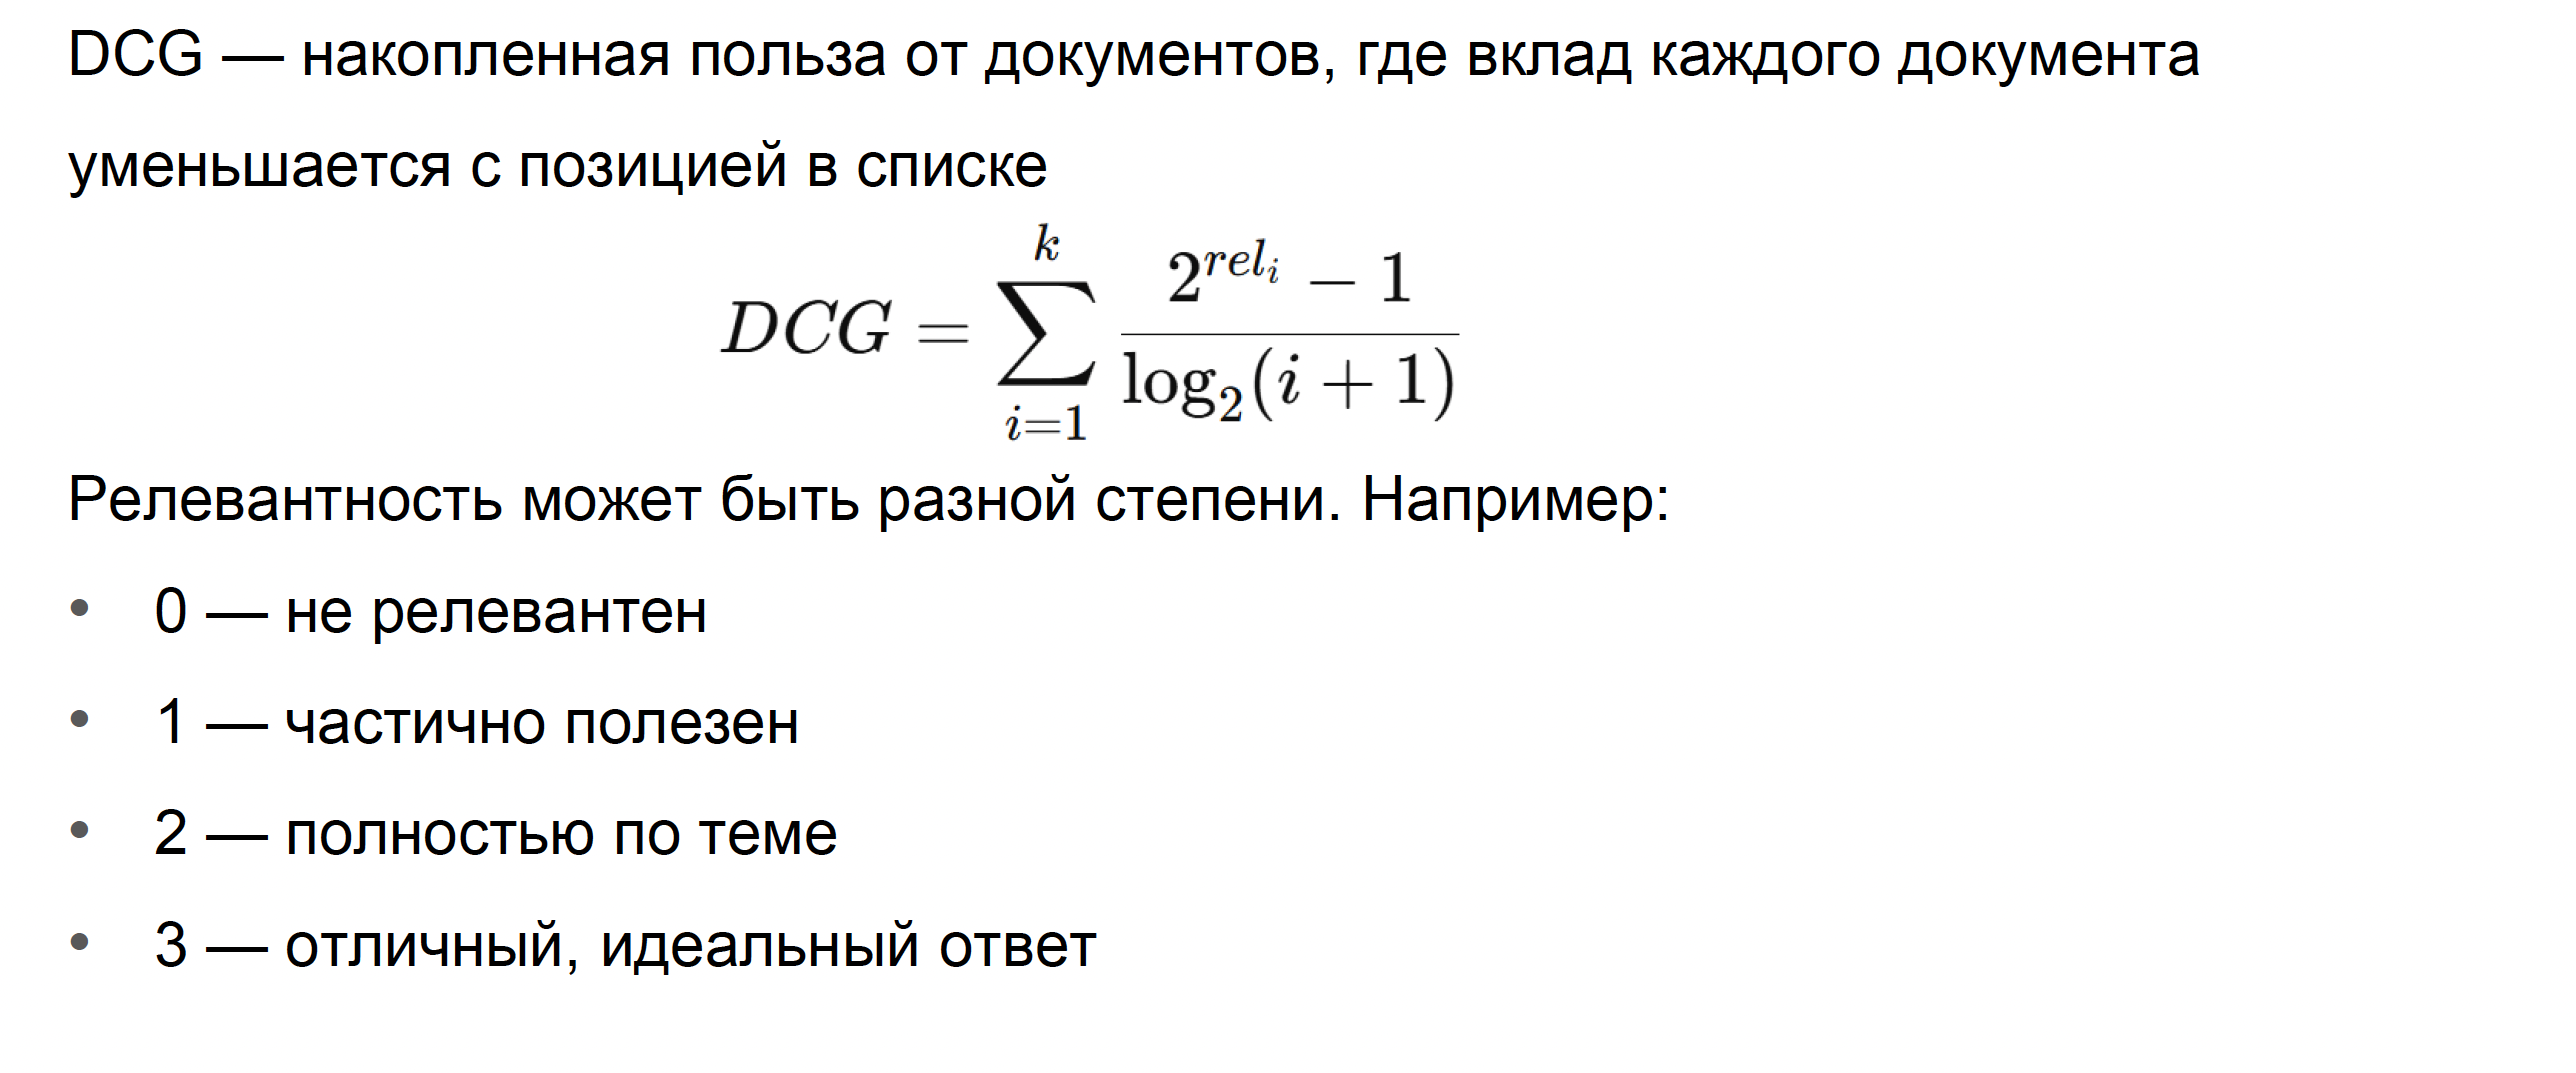

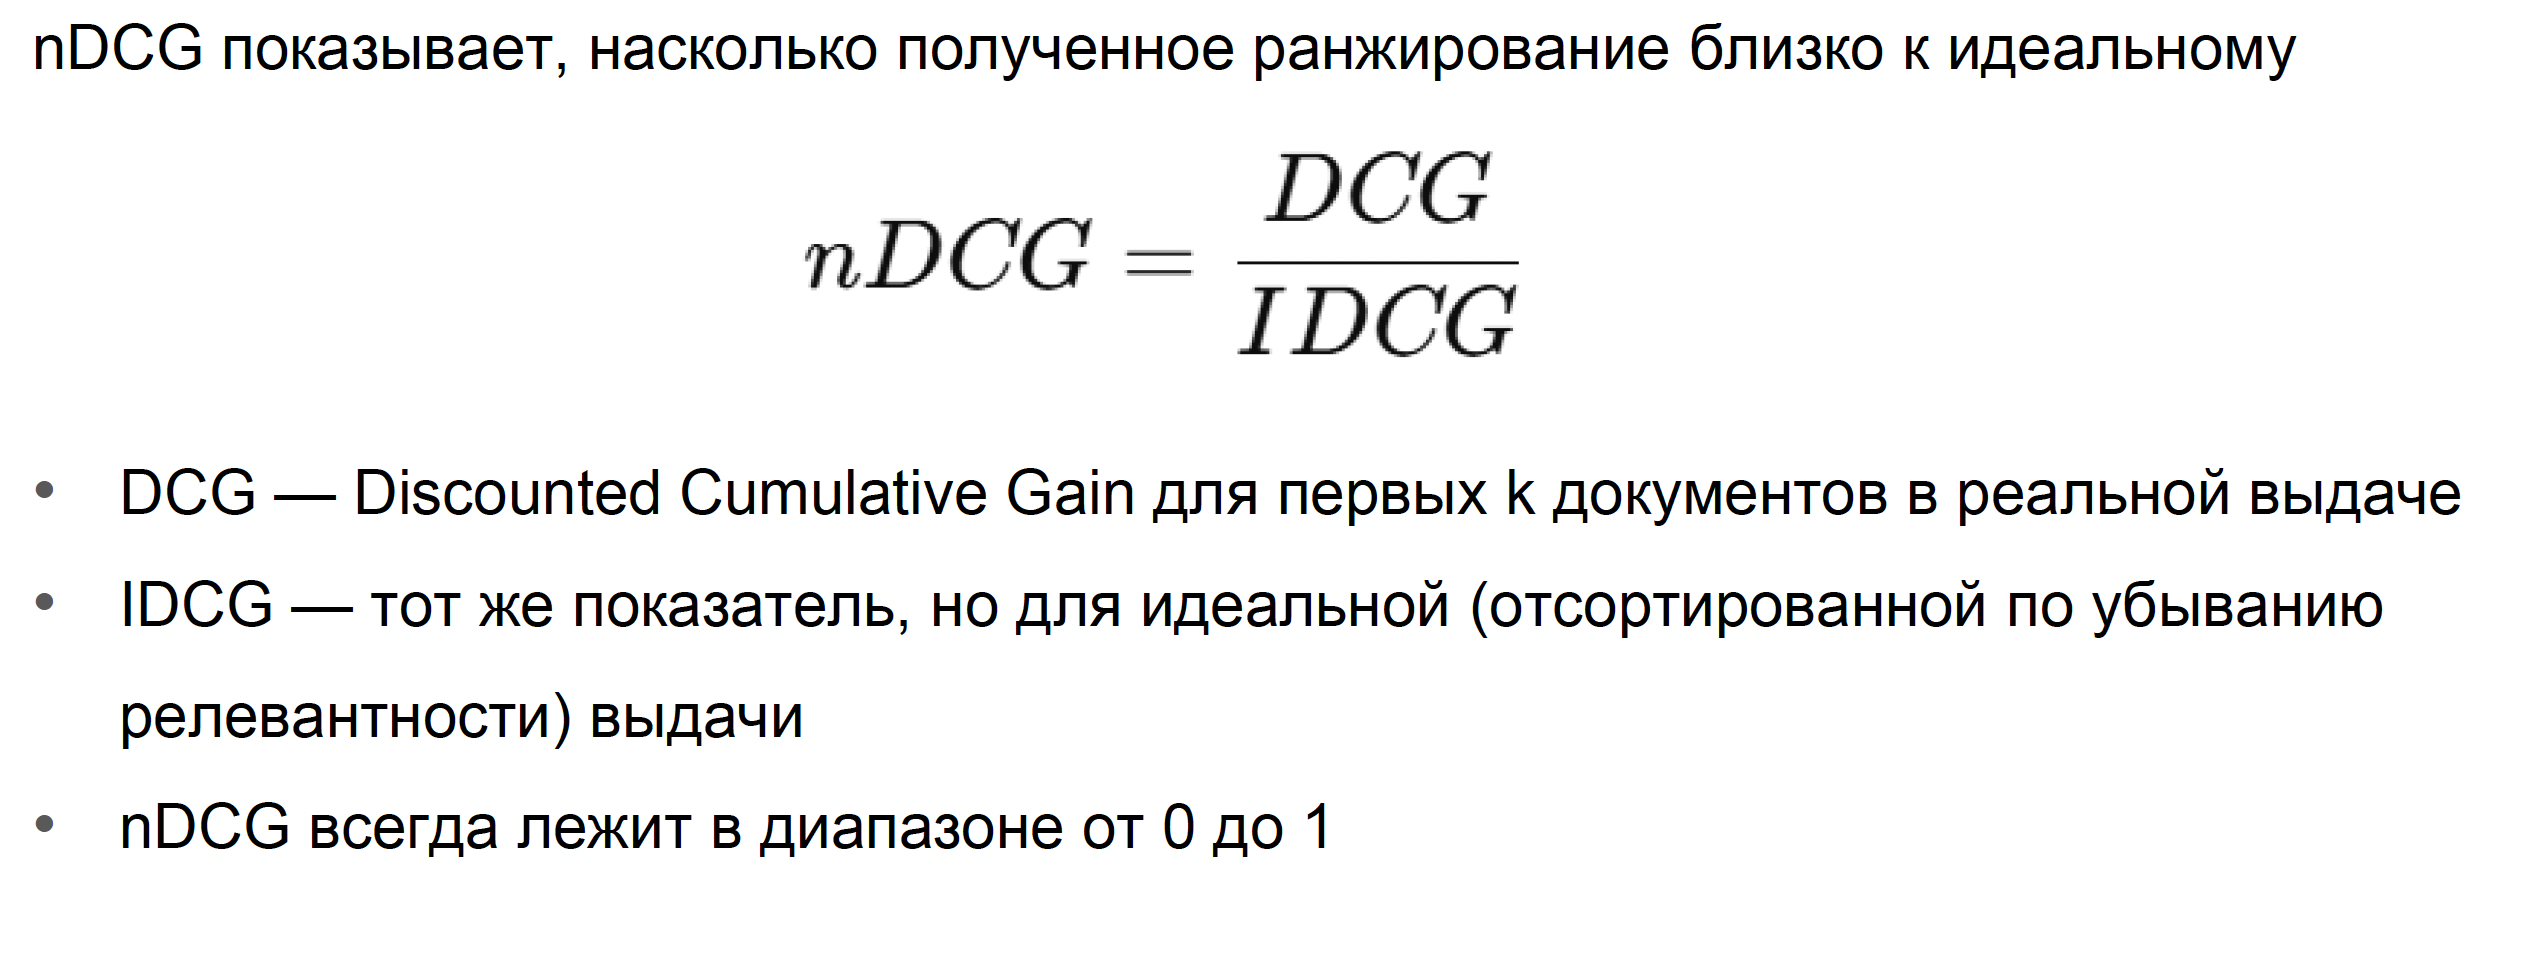

# Задание 2: DCG, nDCG

Реализуйте по формулам функции dcg и ndcg.

In [ ]:
# Релевантность документов по шкале 0–3 (для самопроверки)
rel = [3, 2, 3, 0, 1]

def dcg(rel):
    ...
    return

def ndcg(rel):
    ...
    return

print("nDCG:", ndcg(rel))
# Вывод: nDCG: 0.9574784666412695

Что показывает метрика nDCG?

nDCG оценивает, насколько хорошо ранжированы документы — релевантные должны быть ближе к началу списка.
Значение ближе к 1 означает почти идеальное ранжирование.

Чем nDCG отличается от Precision и Recall?

Precision и Recall учитывают только, нашли ли мы релевантные документы, но не в каком порядке.
nDCG учитывает позиции — ранжирование, что важно для поисковых систем.

Почему пользователи видят только первые страницы выдачи?

Из-за ограниченного внимания: большинство пользователей кликают на первые 3–5 ссылок.
Поэтому хорошее ранжирование особенно важно — метрики вроде nDCG и MAP имитируют это поведение.

Выберем первые два запроса и получим топ-5 документов для TF-IDF и BM25

In [ ]:

# Использование первых двух запросов для вычисления nDCG
selected_queries = [
    "технологии искусственного интеллекта",
    "анализ больших данных"
]

top_n = 5

# Сохраним результаты для выбранных запросов
query_results = {}

for q_idx, query_text in enumerate(selected_queries):
    # Найдём исходный индекс выбранного запроса (если хотим взять какие-то другие запросы из списка)
    original_query_idx = queries.index(query_text)

    # --- TF-IDF результаты по текущему запросу ---
    query_tfidf = preprocessed_queries_tfidf[original_query_idx]
    query_vector_tfidf = vectorizer.transform([query_tfidf])
    cosine_similarities = cosine_similarity(query_vector_tfidf, tfidf_matrix).flatten()

    ranked_docs_tfidf_indices = cosine_similarities.argsort()[:-top_n-1:-1]
    #ranked_docs_tfidf_scores = cosine_similarities[ranked_docs_tfidf_indices]

    # --- BM25 результаты по текущему запросу ---
    query_bm25_tokens = preprocessed_queries_bm25[original_query_idx]
    bm25_scores = bm25.get_scores(query_bm25_tokens)

    ranked_docs_bm25_indices = np.argsort(bm25_scores)[::-1][:top_n]
    #ranked_docs_bm25_scores = bm25_scores[ranked_docs_bm25_indices]

    query_results[query_text] = {
        'tfidf_doc_indices': ranked_docs_tfidf_indices,
        'bm25_doc_indices': ranked_docs_bm25_indices,
        'tfidf_docs': [docs[i] for i in ranked_docs_tfidf_indices],
        'bm25_docs': [docs[i] for i in ranked_docs_bm25_indices]
    }

# Вручную разметим релевантность
# Какие документы нужно разметить (топ-5 для каждого метода совпадали по нашим запросам)
for query_text, data in query_results.items():
    print(f"\n--- Query: '{query_text}' ---")
    print("\n--- TF-IDF Top 5 Documents  ---")
    for i, doc_idx in enumerate(data['tfidf_doc_indices']):
        print(f"  Rank {i+1}, Doc original index: {doc_idx}, Content: {data['tfidf_docs'][i][:150]}...")

    print("\n--- BM25 Top 5 Documents  ---")
    for i, doc_idx in enumerate(data['bm25_doc_indices']):
        print(f"  Rank {i+1}, Doc original index: {doc_idx}, Content: {data['bm25_docs'][i][:150]}...")


Разметим релевантность по нашему усмотрению

In [ ]:

# Query 1: "технологии искусственного интеллекта"
# TF-IDF documents (original indices): [14, 0, 8, 1, 11]
#   Doc 14: Этика в искусственном интеллекте... (Very Relevant: 3)
#   Doc 0: Искусственный интеллект трансформирует... (Very Relevant: 3)
#   Doc 8: Блокчейн технологии... (Slightly Relevant, mentions 'технологии': 1)
#   Doc 1: Машинное обучение играет ключевую роль в современных технологиях... (Relevant: 2)
#   Doc 11: Виртуальная реальность (VR) и дополненная реальность (AR)... (Not Relevant: 0)
rel_tfidf_q1 = [3, 3, 1, 2, 0]
rel_bm25_q1 = [3, 3, 1, 2, 0]

# Query 2: "анализ больших данных"
# TF-IDF documents (original indices): [0, 13, 3, 10, 7]
#   Doc 0: Искусственный интеллект... анализ больших данных. (Very Relevant: 3)
#   Doc 13: Наука о данных включает сбор, обработку, анализ и интерпретацию данных... (Very Relevant: 3)
#   Doc 3: Анализ данных с использованием статистики и алгоритмов... (Relevant: 2)
#   Doc 10: Биоинформатика объединяет биологию и информатику для анализа генетических данных... (Relevant: 2)
#   Doc 7: Кибербезопасность защищает информационные системы... (Slightly Relevant: 1)
rel_tfidf_q2 = [3, 3, 2, 2, 1]
rel_bm25_q2 = [3, 3, 2, 2, 1]

# --- Step 5 & 6: Calculate nDCG and print results ---
print("\n--- nDCG Calculations ---")

print(f"\nQuery: '{selected_queries[0]}'")
print(f"  TF-IDF Relevance: {rel_tfidf_q1}, nDCG: {ndcg(rel_tfidf_q1):.4f}")
print(f"  BM25 Relevance:   {rel_bm25_q1}, nDCG: {ndcg(rel_bm25_q1):.4f}")

print(f"\nQuery: '{selected_queries[1]}'")
print(f"  TF-IDF Relevance: {rel_tfidf_q2}, nDCG: {ndcg(rel_tfidf_q2):.4f}")
print(f"  BM25 Relevance:   {rel_bm25_q2}, nDCG: {ndcg(rel_bm25_q2):.4f}")


### Сравнение nDCG для TF-IDF и BM25

**Запрос 1: 'технологии искусственного интеллекта'**

В данном случае nDCG для обоих методов оказался одинаковым. Это произошло потому, что для этого запроса TF-IDF и BM25 вернули **один и тот же порядок документов** в топ-5, а значит, и релевантность документов на каждой позиции оказалась идентичной. В нашем небольшом и достаточно однородном корпусе, где документы в основном посвящены конкретным технологиям, оба алгоритма смогли эффективно выявить наиболее релевантные документы.

**Запрос 2: 'анализ больших данных'**
*   **TF-IDF nDCG: 1.0000**
*   **BM25 nDCG: 1.0000**

Аналогично первому запросу, для второго запроса nDCG также идентичен и равен 1.0. Это означает, что оба метода идеально ранжировали документы согласно нашей ручной разметке релевантности для этого запроса. Как и в первом случае, это указывает на то, что для данного конкретного набора документов и запросов, обе модели одинаково хорошо справляются с задачей ранжирования.

**Почему nDCG одинаков?**

В условиях этого небольшого и тематически сфокусированного корпуса документов, а также достаточно точных запросов, TF-IDF и BM25 приводят к очень схожим ранжированиям. Но BM25 лучше учитывает длину документа и эффект насыщения терминов, эти преимущества могли не проявиться явно из-за следующих факторов:

1.  **Длина документов:** Возможно, длины документов в корпусе не сильно варьируются или распределение ключевых терминов таково, что корректировки BM25 на длину не привели к существенному изменению ранжирования по сравнению с TF-IDF.
2.  **Частота терминов:** Термины, присутствующие в запросах, могли иметь четкую и однозначную связь с релевантными документами, и их частота в этих документах была достаточно высокой, чтобы оба алгоритма эффективно их обнаружили.
3.  **Небольшой размер корпуса:** На небольших корпусах и с простыми запросами различия между TF-IDF и BM25 могут быть менее заметны, чем на больших, разнородных коллекциях документов.

В реальных, более сложных поисковых системах с тысячами или миллионами документов разной длины и тематики, BM25 обычно демонстрирует превосходство над классическим TF-IDF благодаря корректировкам на длину документа и частоту терминов.

## Теоретическое сравнение моделей поиска и векторных представлений

### Преимущества BM25 перед TF-IDF

BM25 (Okapi BM25) является более сложной и, как правило, более эффективной моделью ранжирования документов по сравнению с TF-IDF, особенно в реальных поисковых системах. Его ключевые преимущества основаны на двух основных принципах:

1.  **Нормализация по длине документа**: TF-IDF может несправедливо отдавать предпочтение более длинным документам, так как в них, естественно, чаще встречаются термины запроса, что искусственно завышает TF. BM25 включает в себя механизм штрафования (или нормализации) длинных документов. Он учитывает среднюю длину документа в корпусе и снижает вес терминов в документах, которые значительно длиннее среднего, предотвращая их доминирование в выдаче. Короткие, но релевантные документы, наоборот, получают небольшой 'бонус'.
2.  **Насыщение частоты термина**: В TF-IDF, чем чаще слово встречается в документе (TF), тем выше его вес, и этот рост может быть линейным или логарифмическим. BM25 вводит "точку насыщения" для частоты термина. Это означает, что после определенного количества вхождений слова в документе, его дополнительное появление оказывает уменьшающееся влияние на общий вес документа. Это отражает тот факт, что чрезмерное повторение одного и того же слова в документе не делает его значительно более релевантным после определенного порога. Благодаря этим особенностям BM25 обычно обеспечивает более точное и интуитивное ранжирование.

### Векторные модели (Word2Vec, BERT) и их преимущества

В отличие от статистических моделей, таких как TF-IDF и BM25, которые работают на уровне отдельных слов (базовая единица – это 'терм' или токен), векторные модели представляют слова и целые тексты в многомерных векторных пространствах. Это позволяет им принципиально улучшить качество поиска:

1.  **Семантическое понимание**: Векторные модели (Word2Vec, FastText) и, в особенности, контекстуальные эмбеддинги (BERT, RoBERTa) способны улавливать семантические отношения между словами. Это означает, что запрос "купить смартфон" может быть сопоставлен с документом, содержащим "приобрести мобильный телефон", даже если точные слова запроса отсутствуют. Это решает проблему синонимов и лексического разрыва (vocabulary mismatch).
2.  **Обработка синонимов и морфологии**: Модели понимают, что слова "бежать", "бежит", "бег" имеют схожий смысл, даже без явной лемматизации или стемминга. Они могут находить релевантные документы, используя не просто совпадения слов, а близость их значений в векторном пространстве.
3.  **Преодоление проблемы разреженности терминов**: TF-IDF и BM25 страдают от проблемы, когда запрос или документ содержат редкие термины, которые недостаточно часто встречаются для получения значимого веса, или когда нет точного совпадения терминов. Векторные модели создают плотные представления, где каждое слово имеет вектор, а значит, даже редкие слова могут быть связаны с другими словами по их смыслу. Это позволяет находить релевантные документы, даже если они используют совершенно другую формулировку.
4.  **Контекстуализация (для BERT и подобных)**: Более продвинутые модели, такие как BERT, создают векторные представления слова в зависимости от его контекста в предложении. Например, слово "замок" будет иметь разные векторы в предложениях "замок принцессы" и "ключ в замке". Это позволяет моделям лучше понимать смысл запроса и документов, повышая точность ранжирования.

Таким образом, векторные модели поднимают поиск на новый уровень, переходя от поиска по ключевым словам к поиску по смыслу, что является критически важным для сложных запросов и большого объема данных.

# Задание 3

Попробуйте подобрать такие документы, для которых BM25 выдаст более точные результаты, чем TF-IDF